# Task 2.1 - Dataset Selection and Setup
**Paper:** Learning Sparse SVM for Feature Selection on Very High Dimensional Datasets (Tan, Wang & Tsang, ICML 2010)

This notebook covers: dataset selection justification, loading, preprocessing, and exploratory data analysis.

**Note:** Run all Part B notebooks from the **partB/** directory so that `results/` and `data/` paths resolve to partB/results/ and partB/data/ (required by the Part B guidelines).

## Random Seed and Hyperparameter Configuration
All seeds and hyperparameters are defined at the top for full reproducibility (Part B requirement).

In [1]:
# Global Configuration -- defined once, referenced everywhere
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# FGM Hyperparameters
B         = 5     # sparsity budget: max features selected (paper parameter B, Section 2)
C         = 0.1   # SVM regularisation (paper Section 3.3: C=0.1 for synthetic data)
MAX_ITER  = 10    # cutting-plane iterations (paper Section 2.7: ~10 iterations suffice)
TEST_SIZE = 0.4   # 60/40 split (matching paper Section 3.4 small dataset protocol)

print("Configuration loaded.")
print(f"  RANDOM_SEED={RANDOM_SEED}, B={B}, C={C}, MAX_ITER={MAX_ITER}")


Configuration loaded.
  RANDOM_SEED=42, B=5, C=0.1, MAX_ITER=10


**What the code does:** Sets all hyperparameters in one place so the rest of the notebook stays consistent. B=5 means FGM selects at most 5 of 34 features. C=0.1 matches the paper's synthetic experiment (Section 3.3). MAX_ITER=10 follows the empirical convergence observation in Section 2.7.

*Paper reference: Section 2 (B parameter), Section 3.3 (C=0.1), Section 2.7 (MAX_ITER).*

## Dataset Justification

**What the dataset is:**
The **Ionosphere dataset** (UCI Machine Learning Repository) contains 351 radar return measurements collected from a phased-array system in Goose Bay, Labrador. Each sample has 34 continuous numeric features from radar signal processing, and a binary label: `'g'` (good -- structure detected in ionosphere) or `'b'` (bad -- signal passed through). It is freely available via `sklearn.datasets.fetch_openml`, no manual download needed.

**Why it is a reasonable testbed for FGM:**
FGM is designed for binary linear classification where only a sparse subset of features is truly informative. The Ionosphere dataset fits this exactly: 34 continuous features are known to include redundant and correlated ones -- a scenario where FGM's sparse feature generation is directly useful. The binary label and real-valued continuous feature structure match the paper's problem setup exactly (Section 2: "Given labeled patterns {x_i, y_i}, x_i in R^m, y_i in {+/-1}").

**Limitations compared to the paper's datasets:**
The paper's key scalability claims are tested on datasets with up to 3.2 million features (URL0, URL1, Table 1). The Ionosphere dataset (34 features, 351 samples) cannot stress-test FGM's scalability. Our reproduction demonstrates the *core sparse feature selection mechanism* and non-monotonic property -- not the large-scale efficiency claim.

**This dataset is NOT used in the original paper.** Table 1 of the paper lists: WDBC, USPS, Breast Cancer, Leukemia, real-sim, rcv1.binary, Arxiv astro-ph, news20.binary, URL0, URL1. Ionosphere is a distinct dataset from a different domain (radar signal processing).


In [2]:
from sklearn.datasets import fetch_openml

# Load Ionosphere -- freely available via OpenML, no manual steps needed
ionosphere = fetch_openml(name='ionosphere', version=1, as_frame=True, parser='auto')
X_raw = ionosphere.data.values.astype(float)
y_raw = ionosphere.target.values

print(f"Dataset: Ionosphere")
print(f"  Samples  : {X_raw.shape[0]}")
print(f"  Features : {X_raw.shape[1]}")
print(f"  Classes  : {list(np.unique(y_raw))}")


Dataset: Ionosphere
  Samples  : 351
  Features : 34
  Classes  : ['b', 'g']


**What the code does:** Fetches the Ionosphere dataset from OpenML so we get the feature matrix X (351 × 34) and label vector y ('g'/'b'). No missing values and no extra manual steps — keeps the pipeline reproducible.

*Paper reference: Section 2 (problem setup x_i in R^m, y_i in {+/-1}).*

In [3]:
# Encode labels to {+1, -1} -- paper uses y_i in {+/-1} throughout Section 2
y = np.where(y_raw == 'g', 1, -1)

print("Label encoding to {+1, -1}:")
for val, name in [(-1, "bad  (b) -- signal passed through"), (1, "good (g) -- structure detected")]:
    count = (y == val).sum()
    print(f"  y={val:+d} ({name}): {count} samples ({100*count/len(y):.1f}%)")


Label encoding to {+1, -1}:
  y=-1 (bad  (b) -- signal passed through): 126 samples (35.9%)
  y=+1 (good (g) -- structure detected): 225 samples (64.1%)


**What the code does:** Maps string labels to {+1, -1} as in the SVM dual formulation. The paper uses y_i ∈ {±1} in Eq. 1 and throughout Section 2.

*Paper reference: Eq. 1 (y_i in {+/-1}), Section 2.*

In [4]:
# Preprocessing: normalise to zero mean, unit variance
# Paper Section 3.1: "each dimension of the data is normalized to zero mean and unit variance"
X_tr_raw, X_te_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_tr_raw)   # fit on train only (no leakage)
X_test  = scaler.transform(X_te_raw)

print(f"Train: {X_train.shape[0]} samples, {X_train.shape[1]} features")
print(f"Test : {X_test.shape[0]} samples")
print(f"Feature mean (train, should ~0): {X_train.mean():.5f}")
print(f"Feature std  (train, should ~1): {X_train.std():.5f}")


Train: 210 samples, 34 features
Test : 141 samples
Feature mean (train, should ~0): 0.00000
Feature std  (train, should ~1): 0.98518


**What the code does:** Applies train/test split and StandardScaler normalisation as in Section 3.1. The scaler is fit only on the training set to avoid leakage — standard practice and consistent with the paper.

*Paper reference: Section 3.1 (normalisation), Section 3.4 (60% train / 40% test split).*

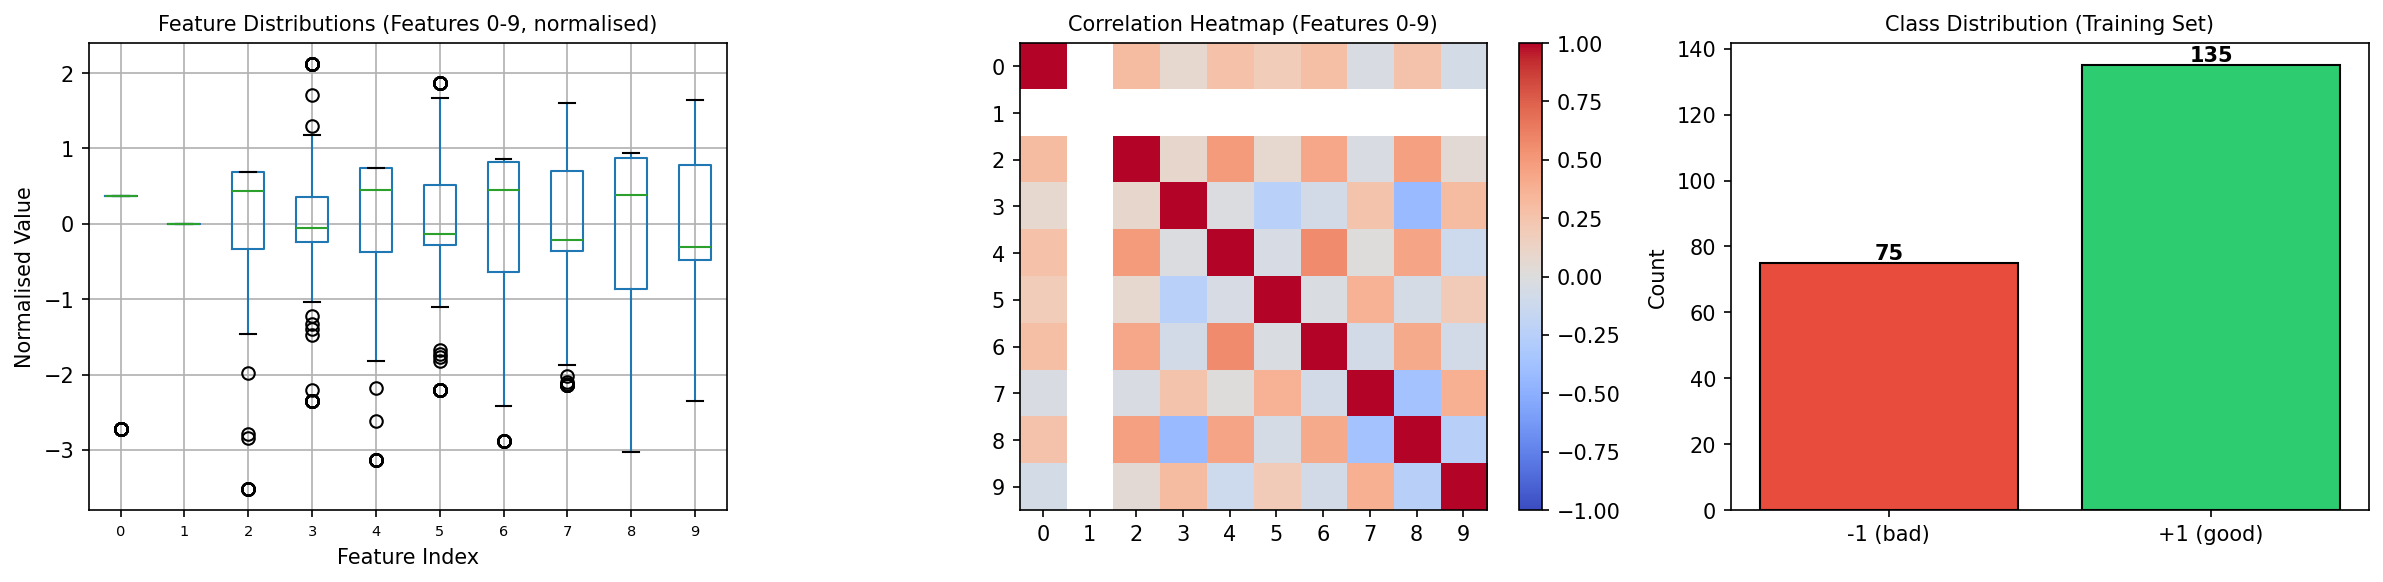

EDA plot saved.


In [ ]:
# Exploratory Data Analysis
import os
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Box plots of first 10 features after normalisation
ax = axes[0]
pd.DataFrame(X_train[:, :10]).boxplot(ax=ax)
ax.set_title("Feature Distributions (Features 0-9, normalised)", fontsize=10)
ax.set_xlabel("Feature Index"); ax.set_ylabel("Normalised Value")
ax.tick_params(axis='x', labelsize=7)

# Correlation heatmap -- shows redundancy motivating sparse selection
ax = axes[1]
corr = np.corrcoef(X_train[:, :10].T)
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_title("Correlation Heatmap (Features 0-9)", fontsize=10)
ax.set_xticks(range(10)); ax.set_yticks(range(10))
plt.colorbar(im, ax=ax, fraction=0.046)

# Class distribution
ax = axes[2]
cls_counts = [(y_train == v).sum() for v in [-1, 1]]
ax.bar(['-1 (bad)', '+1 (good)'], cls_counts, color=['#e74c3c', '#2ecc71'], edgecolor='black')
ax.set_title("Class Distribution (Training Set)", fontsize=10)
ax.set_ylabel("Count")
for i, v in enumerate(cls_counts):
    ax.text(i, v+1, str(v), ha='center', fontweight='bold')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/task_2_1_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA plot saved.")


**What the code does:** Three EDA panels: (1) feature distributions after normalisation; (2) correlation heatmap to show redundancy (motivation for sparse selection in Section 1); (3) class balance for the binary setup.

*Paper reference: Section 1 (motivation for sparsity), Section 3.1 (normalisation verification).*

In [6]:
# Save preprocessed data for downstream notebooks
import os
os.makedirs('data', exist_ok=True)
np.save('data/X_train.npy', X_train)
np.save('data/X_test.npy',  X_test)
np.save('data/y_train.npy', y_train)
np.save('data/y_test.npy',  y_test)
print("Preprocessed data saved to partB/data/")
print(f"  X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"  X_test : {X_test.shape},  y_test : {y_test.shape}")


Preprocessed data saved to partB/data/
  X_train: (210, 34), y_train: (210,)
  X_test : (141, 34),  y_test : (141,)
